In [1]:
import pandas as pd
import numpy as np

# Seteamos una semilla para que los datos sean iguales siempre
np.random.seed(42)

# 1. Creamos 200 registros de clientes
n_clientes = 200

data = {
    'ID_Cliente': range(1001, 1001 + n_clientes),
    'Nombre_Producto': np.random.choice(['Suscripción Premium', 'Crédito Electro', 'Servicio Técnico', 'Plan Básico'], n_clientes),
    'Monto_Deuda': np.random.uniform(500, 15000, n_clientes).round(2),
    'Dias_Vencidos': np.random.randint(0, 150, n_clientes),
    'Pagos_Realizados': np.random.randint(0, 12, n_clientes),
    'Ultimo_Contacto': np.random.choice(['Email', 'WhatsApp', 'Llamada', 'Ninguno'], n_clientes)
}

# 2. Convertimos esto en una tabla (DataFrame)
df = pd.DataFrame(data)

# 3. Mostramos los primeros 10 resultados para verificar
print("¡Base de datos creada exitosamente!")
df.head(10)

¡Base de datos creada exitosamente!


,ID_Cliente,Nombre_Producto,Monto_Deuda,Dias_Vencidos,Pagos_Realizados,Ultimo_Contacto
0,1001,Servicio Técnico,955.72,108,5,WhatsApp
1,1002,Plan Básico,9727.95,115,4,Email
2,1003,Suscripción Premium,5058.16,93,10,Email
3,1004,Servicio Técnico,7874.28,46,11,Email
4,1005,Servicio Técnico,13659.71,98,4,Ninguno
5,1006,Plan Básico,4114.74,54,3,WhatsApp
6,1007,Suscripción Premium,6450.55,51,2,WhatsApp
7,1008,Suscripción Premium,11455.49,143,2,WhatsApp
8,1009,Servicio Técnico,3817.57,12,3,Email
9,1010,Crédito Electro,1616.21,113,8,WhatsApp


In [2]:
# Definimos una función que clasifica según los días vencidos
def segmentar_mora(dias):
    if dias == 0:
        return '0 - Al día'
    elif 1 <= dias <= 30:
        return '1 - Mora Temprana'
    elif 31 <= dias <= 60:
        return '2 - Mora Media'
    elif 61 <= dias <= 90:
        return '3 - Mora Tardía'
    else:
        return '4 - Cobranza Judicial / Crítica'

# Creamos la nueva columna 'Rango_Mora' usando esa función
df['Rango_Mora'] = df['Dias_Vencidos'].apply(segmentar_mora)

# Vamos a ver cuántos clientes hay en cada balde
resumen_mora = df['Rango_Mora'].value_counts().sort_index()

print("Resumen de Clientes por Rango de Mora:")
print(resumen_mora)

Resumen de Clientes por Rango de Mora:
Rango_Mora
0 - Al día                          3
1 - Mora Temprana                  33
2 - Mora Media                     34
3 - Mora Tardía                    37
4 - Cobranza Judicial / Crítica    93
Name: count, dtype: int64


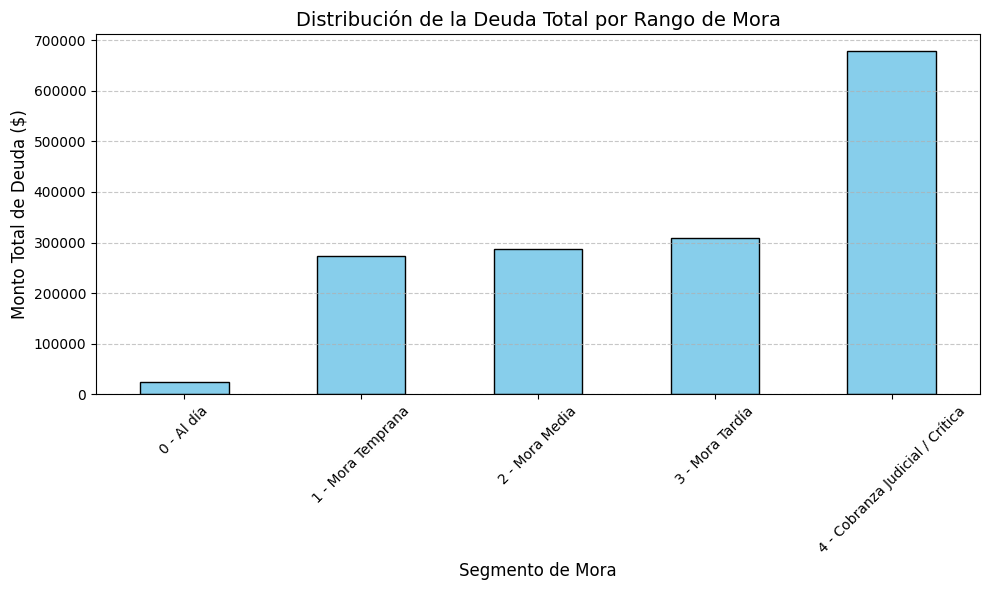

In [3]:
import matplotlib.pyplot as plt

# 1. Agrupamos los datos: sumamos la deuda por cada Rango de Mora
deuda_por_rango = df.groupby('Rango_Mora')['Monto_Deuda'].sum()

# 2. Creamos el gráfico de barras
plt.figure(figsize=(10, 6))
deuda_por_rango.plot(kind='bar', color='skyblue', edgecolor='black')

# 3. Le ponemos títulos profesionales
plt.title('Distribución de la Deuda Total por Rango de Mora', fontsize=14)
plt.xlabel('Segmento de Mora', fontsize=12)
plt.ylabel('Monto Total de Deuda ($)', fontsize=12)
plt.xticks(rotation=45) # Inclinamos las etiquetas para que se lean bien
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Mostramos el gráfico
plt.tight_layout()
plt.show()

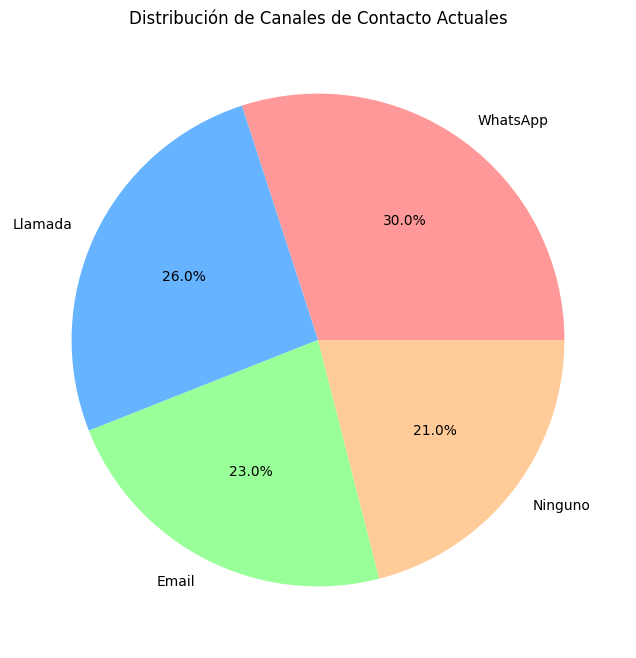

In [4]:
# Contamos cuántas veces usamos cada canal
canales = df['Ultimo_Contacto'].value_counts()

# Creamos un gráfico de torta (pie chart)
plt.figure(figsize=(8, 8))
plt.pie(canales, labels=canales.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title('Distribución de Canales de Contacto Actuales')
plt.show()

In [6]:
# Aplicamos la fórmula de Score de Riesgo
df['Score_Riesgo'] = (df['Dias_Vencidos'] * 0.7) + (df['Monto_Deuda'] / 1000 * 0.3)

# Clasificamos según el Score
def definir_prioridad(score):
    if score > 70: return '🔴 ALTA (Llamada Legal)'
    elif score > 40: return '🟡 MEDIA (Llamada Humana)'
    else: return '🟢 BAJA (Bot/WhatsApp)'

df['Accion_Recomendada'] = df['Score_Riesgo'].apply(definir_prioridad)

# Mostramos los clientes que requieren atención urgente
print("TOP 5 Clientes con Mayor Riesgo:")
df.sort_values(by='Score_Riesgo', ascending=False).head(5)

TOP 5 Clientes con Mayor Riesgo:


,ID_Cliente,Nombre_Producto,Monto_Deuda,Dias_Vencidos,Pagos_Realizados,Ultimo_Contacto,Rango_Mora,Score_Riesgo,Accion_Recomendada
198,1199,Suscripción Premium,9531.91,148,5,Ninguno,4 - Cobranza Judicial / Crítica,106.459573,🔴 ALTA (Llamada Legal)
12,1013,Servicio Técnico,13980.62,146,0,Llamada,4 - Cobranza Judicial / Crítica,106.394186,🔴 ALTA (Llamada Legal)
61,1062,Servicio Técnico,9668.43,146,10,Email,4 - Cobranza Judicial / Crítica,105.100529,🔴 ALTA (Llamada Legal)
13,1014,Servicio Técnico,12217.75,144,0,Email,4 - Cobranza Judicial / Crítica,104.465325,🔴 ALTA (Llamada Legal)
141,1142,Suscripción Premium,14331.96,143,1,Ninguno,4 - Cobranza Judicial / Crítica,104.399588,🔴 ALTA (Llamada Legal)


In [7]:
def generar_mensaje_ia(fila):
    nombre = f"Cliente {fila['ID_Cliente']}"
    monto = fila['Monto_Deuda']

    if "ALTA" in fila['Accion_Recomendada']:
        return f"URGENTE: {nombre}, su deuda de ${monto} ha pasado a instancia legal. Evite recargos llamando hoy."
    elif "MEDIA" in fila['Accion_Recomendada']:
        return f"Hola {nombre}, notamos un retraso en su pago de ${monto}. ¿Podemos ayudarle con un plan de cuotas?"
    else:
        return f"Recordatorio amigable: {nombre}, su factura de ${monto} vence pronto. ¡Gracias por su puntualidad!"

# Creamos una columna con el mensaje sugerido por la "IA"
df['Mensaje_Sugerido'] = df.apply(generar_mensaje_ia, axis=1)

# Ver un ejemplo de cada uno
df[['ID_Cliente', 'Accion_Recomendada', 'Mensaje_Sugerido']].head(10)

,ID_Cliente,Accion_Recomendada,Mensaje_Sugerido
0,1001,🔴 ALTA (Llamada Legal),"URGENTE: Cliente 1001, su deuda de $955.72 ha ..."
1,1002,🔴 ALTA (Llamada Legal),"URGENTE: Cliente 1002, su deuda de $9727.95 ha..."
2,1003,🟡 MEDIA (Llamada Humana),"Hola Cliente 1003, notamos un retraso en su pa..."
3,1004,🟢 BAJA (Bot/WhatsApp),"Recordatorio amigable: Cliente 1004, su factur..."
4,1005,🔴 ALTA (Llamada Legal),"URGENTE: Cliente 1005, su deuda de $13659.71 h..."
5,1006,🟢 BAJA (Bot/WhatsApp),"Recordatorio amigable: Cliente 1006, su factur..."
6,1007,🟢 BAJA (Bot/WhatsApp),"Recordatorio amigable: Cliente 1007, su factur..."
7,1008,🔴 ALTA (Llamada Legal),"URGENTE: Cliente 1008, su deuda de $11455.49 h..."
8,1009,🟢 BAJA (Bot/WhatsApp),"Recordatorio amigable: Cliente 1009, su factur..."
9,1010,🔴 ALTA (Llamada Legal),"URGENTE: Cliente 1010, su deuda de $1616.21 ha..."
